In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/prerana/Documents/Marketing_Conversion_Analytics/data/marketing_conversion.csv")

In [2]:
#Calculating funnel metrics
email_opens = df["EmailOpens"].sum()

email_clicks = df["EmailClicks"].sum()

website_visits = df["WebsiteVisits"].sum()

conversions = df["Conversion"].sum()

funnel_df = pd.DataFrame({
    "Stage": [
        "Email Opens",
        "Email Clicks",
        "Website Visits",
        "Conversions"
    ],
    "Count": [
        email_opens,
        email_clicks,
        website_visits,
        conversions
    ]
})

funnel_df

,Stage,Count
0,Email Opens,75815
1,Email Clicks,35739
2,Website Visits,198013
3,Conversions,7012


In [3]:
#Calculating conversion between stages
open_to_click = (
    email_clicks /
    email_opens
) * 100

click_to_visit = (
    website_visits /
    email_clicks
) * 100

visit_to_conversion = (
    conversions /
    website_visits
) * 100

print(f"Open → Click: {open_to_click:.2f}%")
print(f"Click → Visit: {click_to_visit:.2f}%")
print(f"Visit → Conversion: {visit_to_conversion:.2f}%")

Open → Click: 47.14%
Click → Visit: 554.05%
Visit → Conversion: 3.54%


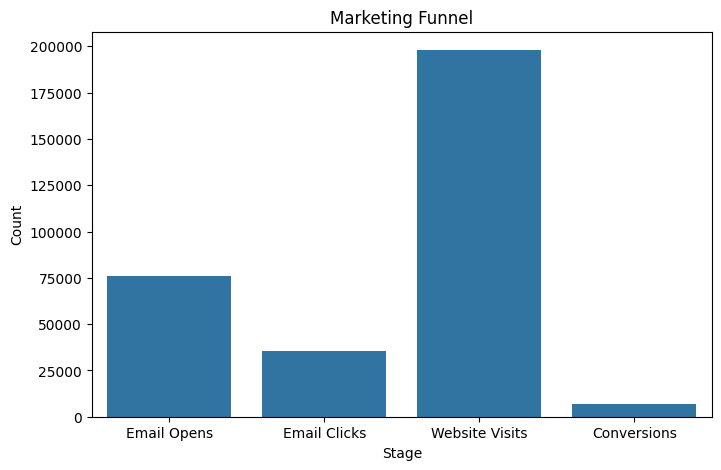

In [4]:
#Visualize Funnel
plt.figure(figsize=(8,5))

sns.barplot(
    data=funnel_df,
    x="Stage",
    y="Count"
)

plt.title("Marketing Funnel")

plt.show()

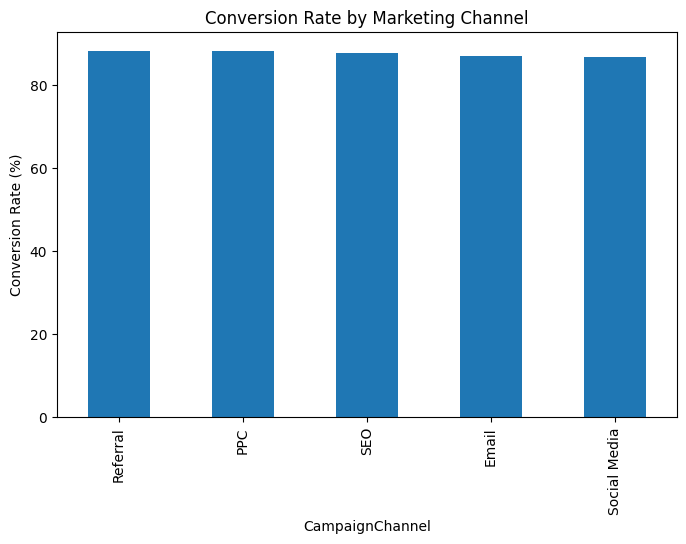

In [5]:
#Segmenting funnel by channel
channel_conversion = (
    df.groupby("CampaignChannel")
      ["Conversion"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

channel_conversion

plt.figure(figsize=(8,5))

channel_conversion.plot(
    kind="bar"
)

plt.title(
    "Conversion Rate by Marketing Channel"
)

plt.ylabel("Conversion Rate (%)")

plt.show()

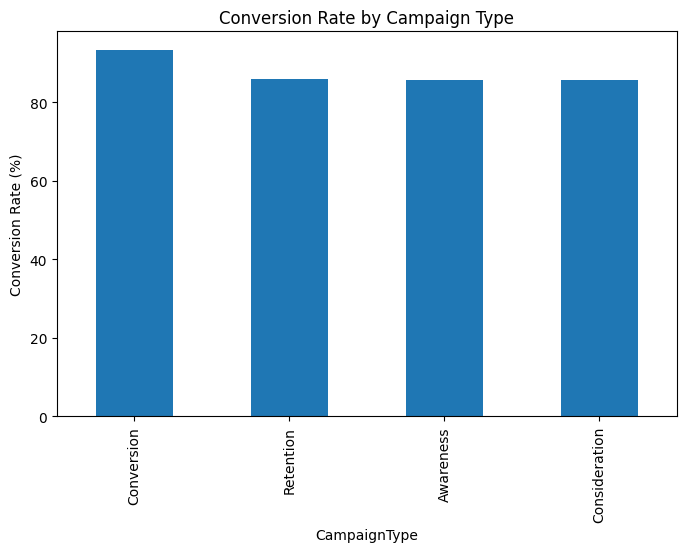

In [6]:
#Segmenting funnel by Campaign type
campaign_conversion = (
    df.groupby("CampaignType")
      ["Conversion"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

campaign_conversion

campaign_conversion.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Conversion Rate by Campaign Type"
)

plt.ylabel(
    "Conversion Rate (%)"
)

plt.show()

In [7]:
#Revenue Opportunity Analysis
avg_order_value = 100
current_revenue = (
    conversions *
    avg_order_value
)

current_revenue

np.int64(701200)

In [8]:
#If conversion increases by 5%
improved_conversions = (
    conversions * 1.05
)

additional_revenue = (
    (improved_conversions - conversions)
    * avg_order_value
)

print(additional_revenue)

35060.00000000004


In [10]:
print("A 5% improvement in conversion could generate approximately $35060 in additional revenue.")

A 5% improvement in conversion could generate approximately $35060 in additional revenue.


In [ ]:
##Key Findings

# Referral and PPC channels generated the highest conversion rates.

# Conversion-focused campaigns significantly outperformed awareness campaigns.

# Email engagement represents the largest opportunity for improving downstream conversion.

# A modest 5% increase in conversion rate could generate meaningful revenue growth.